Task 1 — Autograd Warm-up: Scalars & Computational Graphs

Goal: Get comfortable with requires_grad, .backward(), and .grad on simple scalar expressions before touching any neural network.

1.1 — Manual vs Autograd
Consider the function:

f(x,y)=(x+2y)2+3x

On paper (or in a markdown cell), compute  ∂f∂x  and  ∂f∂y .
Evaluate them at  x=1,y=2 .
Now verify with PyTorch:

In [4]:
import torch

x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

f = (x + 2*y)**2 + 3*x
f.backward()

print(f"df/dx = {x.grad}")  # should match your hand calculation
print(f"df/dy = {y.grad}")

df/dx = 13.0
df/dy = 20.0


In [6]:
x = torch.tensor(3.0, requires_grad=True)

a = x * 2
b = a + 1
c = b ** 2

print(f"a.grad_fn = {a.grad_fn}")
print(f"b.grad_fn = {b.grad_fn}")
print(f"c.grad_fn = {c.grad_fn}")
print(f"x.grad_fn = {x.grad_fn}")  # what do you expect here?

c.backward()
print(f"dc/dx = {x.grad}")

a.grad_fn = <MulBackward0 object at 0x0000022410412F20>
b.grad_fn = <AddBackward0 object at 0x0000022410412F20>
c.grad_fn = <PowBackward0 object at 0x0000022410412F20>
x.grad_fn = None
dc/dx = 28.0


In [61]:
x = torch.tensor(2.0, requires_grad=True)

for i in range(3):
    y = x ** 2
    y.backward()
    print(f"Iteration {i}: x.grad = {x.grad}")
    # we reset gradients here -> x.grad = None / x.grad.zero_()

Iteration 0: x.grad = 4.0
Iteration 1: x.grad = 8.0
Iteration 2: x.grad = 12.0


Why does the gradient keep increasing?

PyTorch adds new gradients instead of overwriting

Fix it by adding x.grad.zero_() at the right place. Where should it go?

shown in code

Why does PyTorch accumulate gradients by default instead of overwriting? (Hint: think about mini-batches.)

When we train with mini-batches the total gradient of network is calculated by the sum of gradients
of mini-batches, thats why pyTorch automatically adds up gradients


Task 2 — Detach, No-grad, and Controlling the Graph

Goal: Understand when and why you'd want to stop gradients from flowing.

In [15]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

with torch.no_grad():
    z = y * 2

print(f"z.requires_grad = {z.requires_grad}")

z.requires_grad = False


In [8]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
z = y.detach() * 2

print(f"z.requires_grad = {z.requires_grad}")
print(f"y.requires_grad = {y.requires_grad}")

z.requires_grad = False
y.requires_grad = True


What's the practical difference between torch.no_grad() and .detach()?



When would you use torch.no_grad() in a training loop? (Think: evaluation, inference.)


When would you use .detach()? (Hint: when you want to use a value from the graph as a constant.)



Task 3 — Linear Regression from Scratch (Raw Tensors Only)

Goal: Build a complete training loop using only torch.Tensor operations — no nn.Module, no nn.Linear, no optim.SGD. You are the optimizer.

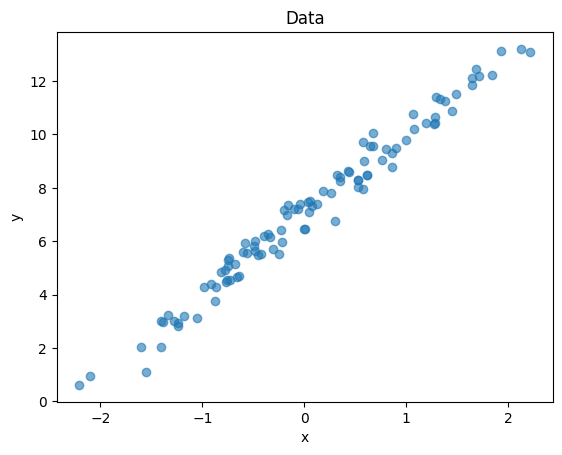

In [37]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

# True relationship: y = 3x + 7 + noise
X = torch.randn(100, 1)
y_true = 3 * X + 7 + 0.5 * torch.randn(100, 1)

plt.scatter(X.numpy(), y_true.numpy(), alpha=0.6)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Data')
plt.show()

In [40]:
# Initialize parameters
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

lr = 0.1
losses = []
for epoch in range(200):
    # Forward pass
    y_pred = w*X + b # TODO: compute prediction using w, b, X

    # Compute MSE loss
    loss = ((y_pred - y_true)**2).mean()

    # Backward pass
    loss.backward()

    # Manual SGD update (no optimizer!)
    with torch.no_grad():
        # TODO: update w and b using their gradients
        w -= lr * w.grad
        b -= lr * b.grad

    # TODO: zero gradients for next iteration
    w.grad.zero_()
    b.grad.zero_()
    losses.append(loss.item())

print(f"Learned: w = {w.item():.3f}, b = {b.item():.3f}")
print(f"True:    w = 3.000, b = 7.000")

Learned: w = 3.006, b = 7.018
True:    w = 3.000, b = 7.000


Task 4 — Binary Classification from Scratch (Logistic Regression)

Goal: Extend your raw-tensor training loop to classification. Implement sigmoid + binary cross-entropy from scratch.

In [43]:
# Data
from sklearn.datasets import make_moons
import numpy as np

X_np, y_np = make_moons(n_samples=500, noise=0.2, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)  # shape: (500, 1)

In [53]:
X_np, y_np = make_moons(n_samples=500, noise=0.2, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)  # shape: (500, 1)
# Parameters: 2 inputs -> 1 output
W = torch.randn(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.5
losses = []

for epoch in range(500):
    # Forward: logistic regression
    logits = X @ W + b
    probs = torch.sigmoid(logits)

    # Binary cross-entropy (implement manually, don't use F.binary_cross_entropy)
    # BCE = -1/N * sum(y*log(p) + (1-y)*log(1-p))
    eps = 1e-7  # for numerical stability
    loss = -( y * torch.log(probs + eps) + (1 - y) * torch.log(1 - probs + eps) ).mean()

    loss.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

    W.grad.zero_()
    b.grad.zero_()

    losses.append(loss.item())

    if epoch % 100 == 0:
        acc = ((probs > 0.5).float() == y).float().mean()
        print(f"Epoch {epoch}: loss={loss.item():.4f}, acc={acc.item():.3f}")

Epoch 0: loss=0.6904, acc=0.554
Epoch 100: loss=0.3028, acc=0.852
Epoch 200: loss=0.2864, acc=0.858
Epoch 300: loss=0.2821, acc=0.856
Epoch 400: loss=0.2807, acc=0.860


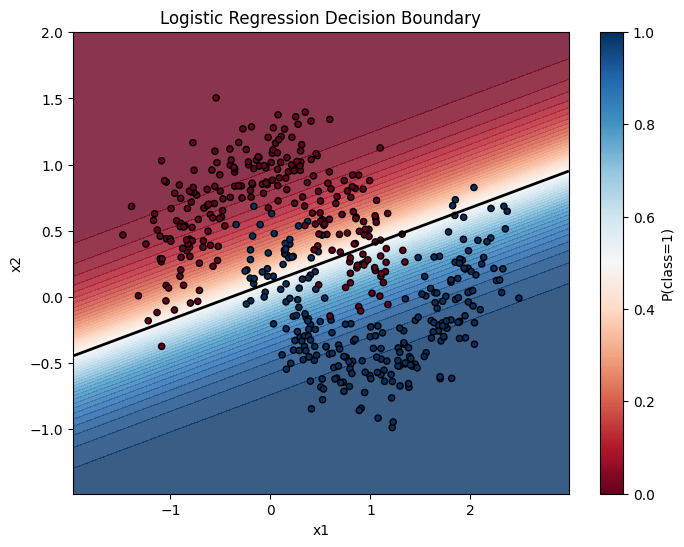

In [54]:
def plot_decision_boundary_logreg(X, y, W, b):
    # Create mesh grid over the input space
    x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
    y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Flatten grid into (N, 2) tensor and pass through model
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        logits = grid @ W + b
        probs = torch.sigmoid(logits)

    # Reshape back to grid shape for plotting
    Z = probs.numpy().reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.8)   # soft probability heatmap
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)  # decision boundary line
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap='RdBu', edgecolors='k', s=20)
    plt.title('Logistic Regression Decision Boundary')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.colorbar(label='P(class=1)')
    plt.show()

plot_decision_boundary_logreg(X, y, W, b)

Now extend your model to a 2-layer network (2 → 16 → 1) using raw tensors:

In [52]:
# Layer 1
W1 = (torch.randn(2, 16) * 0.1).requires_grad_(True)
b1 = torch.zeros(16, requires_grad=True)

# Layer 2
W2 = (torch.randn(16, 1) * 0.1).requires_grad_(True)
b2 = torch.zeros(1, requires_grad=True)

lr = 0.5

for epoch in range(1000):
    # Forward
    h = torch.relu(X @ W1 + b1)     # hidden layer with ReLU
    logits = h @ W2 + b2
    probs = torch.sigmoid(logits)

    # BCE loss
    eps = 1e-7
    loss = -torch.mean(y * torch.log(probs + eps) + (1 - y) * torch.log(1 - probs + eps))

    loss.backward()

    with torch.no_grad():
        # TODO: update all four parameters
        W1 -= lr * W1.grad
        b1 -= lr * b1.grad
        W2 -= lr * W2.grad
        b2 -= lr * b2.grad

    # TODO: zero all gradients
    W1.grad.zero_()
    b1.grad.zero_()
    W2.grad.zero_()
    b2.grad.zero_()

    if epoch % 100 == 0:
        acc = ((probs > 0.5).float() == y).float().mean()
        print(f"Epoch {epoch}: loss={loss.item():.4f}, acc={acc.item():.3f}")

Epoch 0: loss=0.6984, acc=0.324
Epoch 100: loss=0.2783, acc=0.860
Epoch 200: loss=0.2720, acc=0.864
Epoch 300: loss=0.2637, acc=0.864
Epoch 400: loss=0.2564, acc=0.870
Epoch 500: loss=0.2509, acc=0.870
Epoch 600: loss=0.2404, acc=0.876
Epoch 700: loss=0.2076, acc=0.896
Epoch 800: loss=0.1584, acc=0.936
Epoch 900: loss=0.1228, acc=0.962


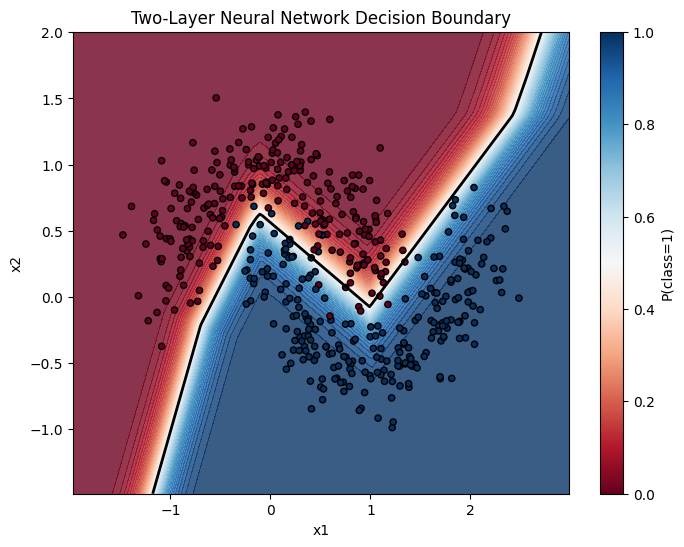

In [56]:
def plot_decision_boundary_nn(X, y, W1, b1, W2, b2):
    # Create mesh grid over the input space
    x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
    y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Flatten grid into (N, 2) tensor and pass through model
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        h = torch.relu(grid @ W1 + b1)
        logits = h @ W2 + b2
        probs = torch.sigmoid(logits)

    # Reshape back to grid shape for plotting
    Z = probs.numpy().reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.8)          # soft probability heatmap
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)  # decision boundary line
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap='RdBu', edgecolors='k', s=20)
    plt.title('Two-Layer Neural Network Decision Boundary')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.colorbar(label='P(class=1)')
    plt.show()

plot_decision_boundary_nn(X, y, W1, b1, W2, b2)